# Análisis de resultados — Efecto Túnel Cuántico (TDSE)

Este notebook analiza los resultados del estudio de sensibilidad sobre la PINN
aplicada a la ecuación de Schrödinger dependiente del tiempo (TDSE) para el
efecto túnel cuántico. La PINN aprende la función de onda compleja Ψ(x,t) = u(x,t) + iv(x,t)
a partir de condiciones iniciales, condiciones de contorno y la restricción física
de la TDSE. Se estudian los siguientes ejes:

1. **Puntos de colocación**: 1000, 2000, 5000 (base), 10000
2. **Sampler**: LHS (base) vs. grid
3. **Optimizador**: Adam (base) vs. Adam+L-BFGS
4. **Arquitectura**: [64,64,64,64] (base) vs. [128,128,128,128]
5. **Learning rate**: 0.001 (base) vs. 0.01
6. **Warmup epochs**: 0, 2500, 5000 (base), 7500
7. **Altura de barrera V₀**: 2.5, 3.0 (base), 5.0
8. **Puntos de entrenamiento**: 20, 50, 100 (base), 200
9. **PINN con/sin datos**: con datos (base) vs. sin datos
10. **Pesos dinámicos**: desactivados (base) vs. activados

Cada configuración se ejecuta con 10 seeds distintas.
La referencia numérica es Crank-Nicolson (TDSE).
El error L2 se calcula como media sobre snapshots temporales: t=0, t=1.0, t=2.0, t=3.0.
La métrica adicional clave es el coeficiente de transmisión T = ∫_{x>barrera} |Ψ|² dx.

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

mpl.rcParams.update({
    "font.family":         "serif",
    "font.size":           12,
    "axes.linewidth":      1.2,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi":          150,
})

RESULTS_DIR = Path("results")
FIGS_DIR    = Path("figures_analysis_tunnel")
FIGS_DIR.mkdir(exist_ok=True)

C_PINN = "#1f4e96"
C_NN   = "#e07b39"
C_CN   = "#888888"

V0_BASE = 3.0
T_CN_REF = 0.10658369331350724  # coeficiente de transmisión CN en configuración base

In [2]:
records_tunnel = []

for fpath in sorted(RESULTS_DIR.glob("tunnel/**/*.json")):
    with open(fpath) as f:
        d = json.load(f)

    cfg = d["config"]
    res = d["resultados_finales"]

    records_tunnel.append({
        # ── Configuración ──────────────────────────────────────────
        "seed":                cfg["seed"],
        "epochs":              cfg["epochs"],
        "lr":                  cfg["lr"],
        "num_collocation":     cfg["num_collocation"],
        "num_ic_points":       cfg["num_ic_points"],
        "num_bc_points":       cfg["num_bc_points"],
        "num_train_points":    cfg["num_train_points"],
        "sampler":             cfg["sampler"],
        "warmup_epochs":       cfg["warmup_epochs"],
        "use_dynamic_weights": cfg["use_dynamic_weights"],
        "use_data_pinn":       cfg["use_data_pinn"],
        "optimizer":           cfg["optimizer"],
        "hidden_layers":       str(cfg["hidden_layers"]),
        "V0":                  cfg["V0"],
        "k0":                  cfg["k0"],
        # ── Resultados PINN ────────────────────────────────────────
        "error_l2_pinn":       res["pinn"]["error_L2_mean"],
        "time_pinn":           res["pinn"]["time_s"],
        "T_pinn":              res["pinn"]["T_pinn"],
        # ── Resultados NN pura ─────────────────────────────────────
        "error_l2_nn":         res["nn"]["error_L2_mean"],
        "time_nn":             res["nn"]["time_s"],
        "T_nn":                res["nn"]["T_nn"],
        # ── Resultados Crank-Nicolson ──────────────────────────────
        "time_cn":             res["crank_nicolson"]["time_s"],
        "T_cn":                res["crank_nicolson"]["T_cn"],
    })

df_tunnel = pd.DataFrame(records_tunnel)
print(f"Total experimentos cargados: {len(df_tunnel)}")
print(f"Valores de num_collocation: {sorted(df_tunnel['num_collocation'].unique())}")
print(f"Valores de warmup_epochs:   {sorted(df_tunnel['warmup_epochs'].unique())}")
print(f"Valores de V0:              {sorted(df_tunnel['V0'].unique())}")
df_tunnel.head()

Total experimentos cargados: 180
Valores de num_collocation: [1000, 2000, 5000, 10000]
Valores de warmup_epochs:   [0, 2500, 5000, 7500]
Valores de V0:              [2.5, 3.0, 5.0]


,seed,epochs,lr,num_collocation,num_ic_points,num_bc_points,num_train_points,sampler,warmup_epochs,use_dynamic_weights,...,V0,k0,error_l2_pinn,time_pinn,T_pinn,error_l2_nn,time_nn,T_nn,time_cn,T_cn
0,42,20000,0.001,5000,500,200,100,grid,5000,False,...,3.0,2.0,0.718129,469.748207,0.070031,0.691133,38.276694,0.147700,0.015006,0.106584
1,123,20000,0.001,5000,500,200,100,grid,5000,False,...,3.0,2.0,0.700254,468.801414,0.100285,0.555577,37.929665,0.133895,0.014229,0.106584
2,7,20000,0.001,5000,500,200,100,grid,5000,False,...,3.0,2.0,0.588545,469.218280,0.097788,0.598315,37.933590,0.151912,0.015002,0.106584
3,99,20000,0.001,5000,500,200,100,grid,5000,False,...,3.0,2.0,0.784693,468.372251,0.128694,0.687675,37.992662,0.211278,0.015337,0.106584
4,2024,20000,0.001,5000,500,200,100,grid,5000,False,...,3.0,2.0,0.557585,468.980076,0.107842,0.749581,38.082777,0.312741,0.013989,0.106584


In [3]:
BASE_TUNNEL = {
    "num_collocation":     5000,
    "num_train_points":    100,
    "sampler":             "lhs",
    "warmup_epochs":       5000,
    "use_dynamic_weights": False,
    "use_data_pinn":       True,
    "optimizer":           "adam",
    "hidden_layers":       "[64, 64, 64, 64]",
    "lr":                  0.001,
    "V0":                  3.0,
}

def is_base_tunnel(row):
    return all(row[k] == v for k, v in BASE_TUNNEL.items())

df_tunnel["is_base"] = df_tunnel.apply(is_base_tunnel, axis=1)
df_base_tunnel = df_tunnel[df_tunnel["is_base"]]

print(f"Experimentos BASE: {len(df_base_tunnel)} (esperados: 10)")
print(f"\nError L2 PINN — media: {df_base_tunnel['error_l2_pinn'].mean():.4e} "
      f"± {df_base_tunnel['error_l2_pinn'].std():.4e}")
print(f"Error L2 NN   — media: {df_base_tunnel['error_l2_nn'].mean():.4e} "
      f"± {df_base_tunnel['error_l2_nn'].std():.4e}")
print(f"\nCoef. transmisión PINN — media: {df_base_tunnel['T_pinn'].mean():.4f} "
      f"± {df_base_tunnel['T_pinn'].std():.4f}")
print(f"Coef. transmisión NN   — media: {df_base_tunnel['T_nn'].mean():.4f} "
      f"± {df_base_tunnel['T_nn'].std():.4f}")
print(f"Coef. transmisión CN   — media: {df_base_tunnel['T_cn'].mean():.4f} "
      f"± {df_base_tunnel['T_cn'].std():.4f}")
print(f"\nTiempo PINN — media: {df_base_tunnel['time_pinn'].mean():.2f}s "
      f"± {df_base_tunnel['time_pinn'].std():.2f}s")
print(f"Tiempo NN   — media: {df_base_tunnel['time_nn'].mean():.2f}s "
      f"± {df_base_tunnel['time_nn'].std():.2f}s")
print(f"Tiempo CN   — media: {df_base_tunnel['time_cn'].mean():.4f}s")

Experimentos BASE: 10 (esperados: 10)

Error L2 PINN — media: 5.1203e-01 ± 2.4472e-02
Error L2 NN   — media: 6.4365e-01 ± 5.7102e-02

Coef. transmisión PINN — media: 0.0691 ± 0.0106
Coef. transmisión NN   — media: 0.1910 ± 0.0611
Coef. transmisión CN   — media: 0.1066 ± 0.0000

Tiempo PINN — media: 463.03s ± 0.68s
Tiempo NN   — media: 37.94s ± 0.16s
Tiempo CN   — media: 0.0148s


## Eje 1 — Puntos de colocación

Se varía el número de puntos de colocación en el dominio 2D (x,t) entre 1000
y 10000. La NN pura no depende de este parámetro y se representa como
referencia horizontal. Además del error L2 se analiza el efecto sobre el
coeficiente de transmisión T.

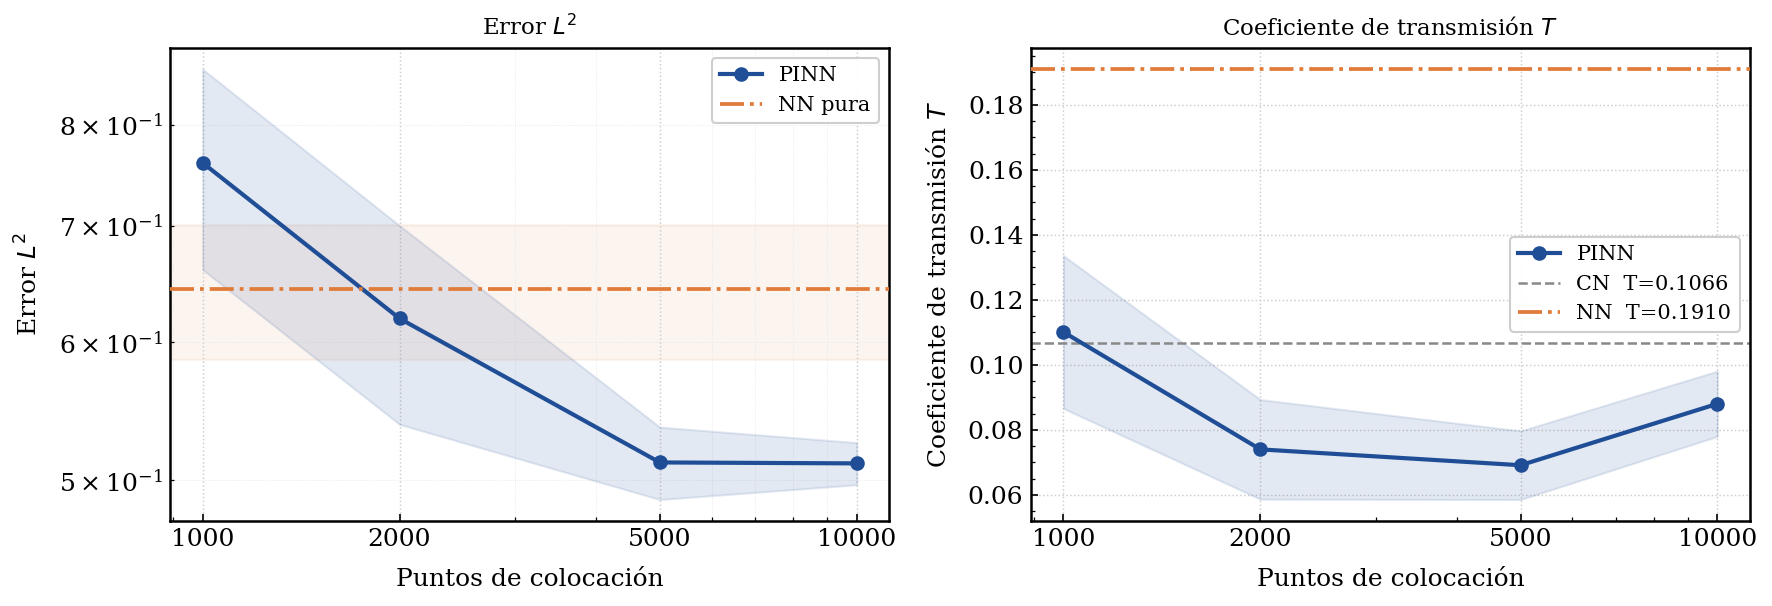

NN pura: 6.4365e-01 ± 5.7102e-02
T_cn:    0.1066

   pts      PINN L2     T_pinn    T_std
  1000   7.6057e-01     0.1101   0.0235
  2000   6.1924e-01     0.0740   0.0153
  5000   5.1203e-01     0.0691   0.0106
 10000   5.1139e-01     0.0880   0.0100


In [4]:
configs_eje1 = [1000, 2000, 5000, 10000]

mask_eje1_tunnel = (
    df_tunnel["num_collocation"].isin(configs_eje1) &
    (df_tunnel["num_train_points"]    == BASE_TUNNEL["num_train_points"]) &
    (df_tunnel["sampler"]             == BASE_TUNNEL["sampler"]) &
    (df_tunnel["warmup_epochs"]       == BASE_TUNNEL["warmup_epochs"]) &
    (df_tunnel["use_dynamic_weights"] == BASE_TUNNEL["use_dynamic_weights"]) &
    (df_tunnel["use_data_pinn"]       == BASE_TUNNEL["use_data_pinn"]) &
    (df_tunnel["optimizer"]           == BASE_TUNNEL["optimizer"]) &
    (df_tunnel["hidden_layers"]       == BASE_TUNNEL["hidden_layers"]) &
    (df_tunnel["lr"]                  == BASE_TUNNEL["lr"]) &
    (df_tunnel["V0"]                  == BASE_TUNNEL["V0"])
)

df_eje1_tunnel = df_tunnel[mask_eje1_tunnel].groupby("num_collocation").agg(
    pinn_mean =("error_l2_pinn", "mean"),
    pinn_std  =("error_l2_pinn", "std"),
    T_pinn_mean=("T_pinn",       "mean"),
    T_pinn_std =("T_pinn",       "std"),
).reset_index()

x   = df_eje1_tunnel["num_collocation"].values
y_p = df_eje1_tunnel["pinn_mean"].values
s_p = df_eje1_tunnel["pinn_std"].values
y_nn = df_base_tunnel["error_l2_nn"].mean()
s_nn = df_base_tunnel["error_l2_nn"].std()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, y_p, "o-", color=C_PINN, linewidth=2, markersize=6,
        zorder=3, label="PINN")
ax.fill_between(x, y_p - s_p, y_p + s_p,
                color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(y_nn, color=C_NN, linewidth=1.8, linestyle="-.",
           zorder=3, label="NN pura")
ax.axhspan(y_nn - s_nn, y_nn + s_nn,
           color=C_NN, alpha=0.08, zorder=1)
ax.set_xlabel("Puntos de colocación", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(configs_eje1)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel derecho: coeficiente de transmisión ─────────────────────────────
ax = axes[1]
ax.plot(x, df_eje1_tunnel["T_pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3, label="PINN")
ax.fill_between(x,
    df_eje1_tunnel["T_pinn_mean"] - df_eje1_tunnel["T_pinn_std"],
    df_eje1_tunnel["T_pinn_mean"] + df_eje1_tunnel["T_pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(df_base_tunnel["T_cn"].mean(), color=C_CN, linewidth=1.2,
           linestyle="--", label=f"CN  T={df_base_tunnel['T_cn'].mean():.4f}", zorder=2)
ax.axhline(df_base_tunnel["T_nn"].mean(), color=C_NN, linewidth=1.8,
           linestyle="-.", label=f"NN  T={df_base_tunnel['T_nn'].mean():.4f}", zorder=3)
ax.set_xlabel("Puntos de colocación", labelpad=8)
ax.set_ylabel("Coeficiente de transmisión $T$", labelpad=8)
ax.set_xscale("log")
ax.set_xticks(configs_eje1)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Coeficiente de transmisión $T$", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje1_colocation_points.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"NN pura: {y_nn:.4e} ± {s_nn:.4e}")
print(f"T_cn:    {df_base_tunnel['T_cn'].mean():.4f}")
print(f"\n{'pts':>6} {'PINN L2':>12} {'T_pinn':>10} {'T_std':>8}")
for _, row in df_eje1_tunnel.iterrows():
    print(f"{int(row['num_collocation']):>6} {row['pinn_mean']:>12.4e} "
          f"{row['T_pinn_mean']:>10.4f} {row['T_pinn_std']:>8.4f}")

## Eje 2 — Sampler

Se compara LHS frente a malla uniforme para los puntos de colocación 2D.
El sampler no afecta a la NN pura, que se representa como referencia horizontal.

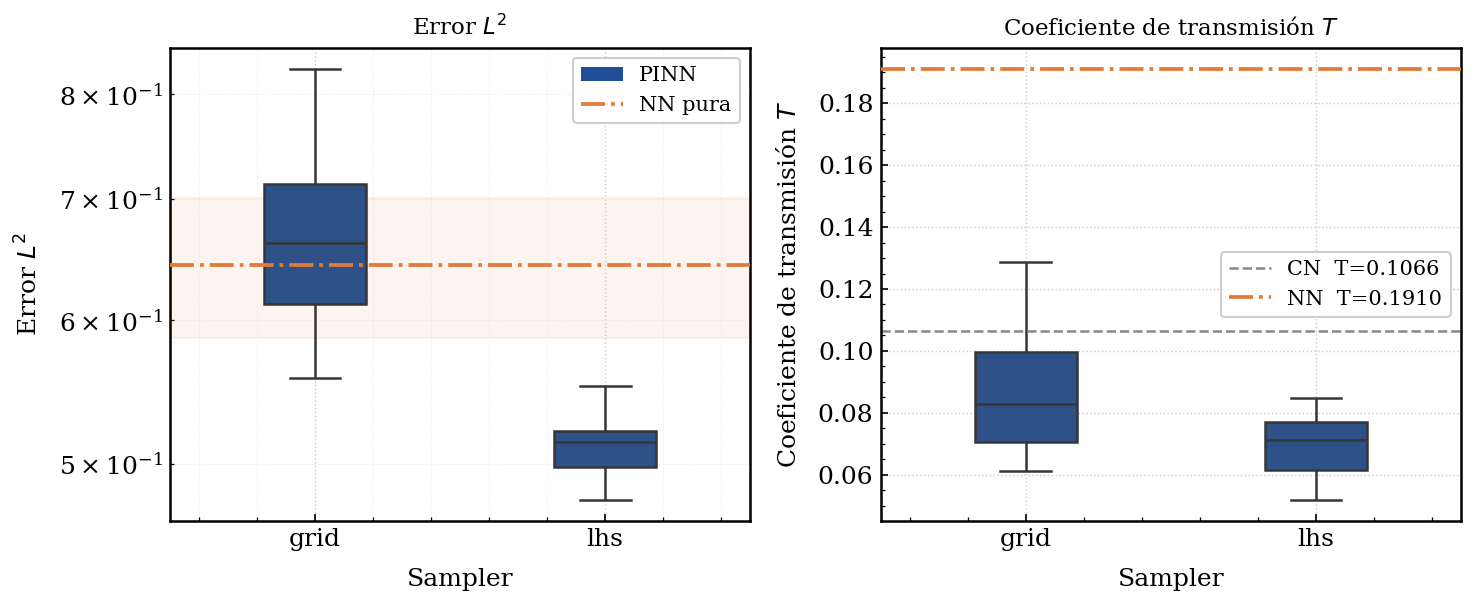

grid: L2=6.7374e-01 ± 8.5847e-02 | T=0.0873 ± 0.0212
lhs: L2=5.1203e-01 ± 2.4472e-02 | T=0.0691 ± 0.0106
NN pura: 6.4365e-01 ± 5.7102e-02
T_cn:    0.1066


In [5]:
mask_eje2_tunnel = (
    df_tunnel["sampler"].isin(["lhs", "grid"]) &
    (df_tunnel["num_collocation"]     == BASE_TUNNEL["num_collocation"]) &
    (df_tunnel["num_train_points"]    == BASE_TUNNEL["num_train_points"]) &
    (df_tunnel["warmup_epochs"]       == BASE_TUNNEL["warmup_epochs"]) &
    (df_tunnel["use_dynamic_weights"] == BASE_TUNNEL["use_dynamic_weights"]) &
    (df_tunnel["use_data_pinn"]       == BASE_TUNNEL["use_data_pinn"]) &
    (df_tunnel["optimizer"]           == BASE_TUNNEL["optimizer"]) &
    (df_tunnel["hidden_layers"]       == BASE_TUNNEL["hidden_layers"]) &
    (df_tunnel["lr"]                  == BASE_TUNNEL["lr"]) &
    (df_tunnel["V0"]                  == BASE_TUNNEL["V0"])
)

df_eje2_tunnel = df_tunnel[mask_eje2_tunnel].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df_eje2_tunnel, x="sampler", y="error_l2_pinn",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(df_base_tunnel["error_l2_nn"].mean(), color=C_NN,
           linewidth=1.8, linestyle="-.", label="NN pura", zorder=3)
ax.axhspan(
    df_base_tunnel["error_l2_nn"].mean() - df_base_tunnel["error_l2_nn"].std(),
    df_base_tunnel["error_l2_nn"].mean() + df_base_tunnel["error_l2_nn"].std(),
    color=C_NN, alpha=0.08, zorder=1
)
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Sampler", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: coeficiente de transmisión ─────────────────────────────
ax = axes[1]
sns.boxplot(
    data=df_eje2_tunnel, x="sampler", y="T_pinn",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(df_base_tunnel["T_cn"].mean(), color=C_CN, linewidth=1.2,
           linestyle="--", label=f"CN  T={df_base_tunnel['T_cn'].mean():.4f}", zorder=2)
ax.axhline(df_base_tunnel["T_nn"].mean(), color=C_NN, linewidth=1.8,
           linestyle="-.", label=f"NN  T={df_base_tunnel['T_nn'].mean():.4f}", zorder=3)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Sampler", labelpad=8)
ax.set_ylabel("Coeficiente de transmisión $T$", labelpad=8)
ax.set_title("Coeficiente de transmisión $T$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje2_sampler.png", dpi=300, bbox_inches="tight")
plt.show()

for sampler, grp in df_tunnel[mask_eje2_tunnel].groupby("sampler"):
    print(f"{sampler}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| T={grp['T_pinn'].mean():.4f} ± {grp['T_pinn'].std():.4f}")
print(f"NN pura: {df_base_tunnel['error_l2_nn'].mean():.4e} ± {df_base_tunnel['error_l2_nn'].std():.4e}")
print(f"T_cn:    {df_base_tunnel['T_cn'].mean():.4f}")

## Eje 3 — Optimizador

Se compara Adam (BASE) frente a Adam+L-BFGS. El optimizador afecta tanto
a la PINN como a la NN, por lo que se incluyen ambas en el panel de error L2.

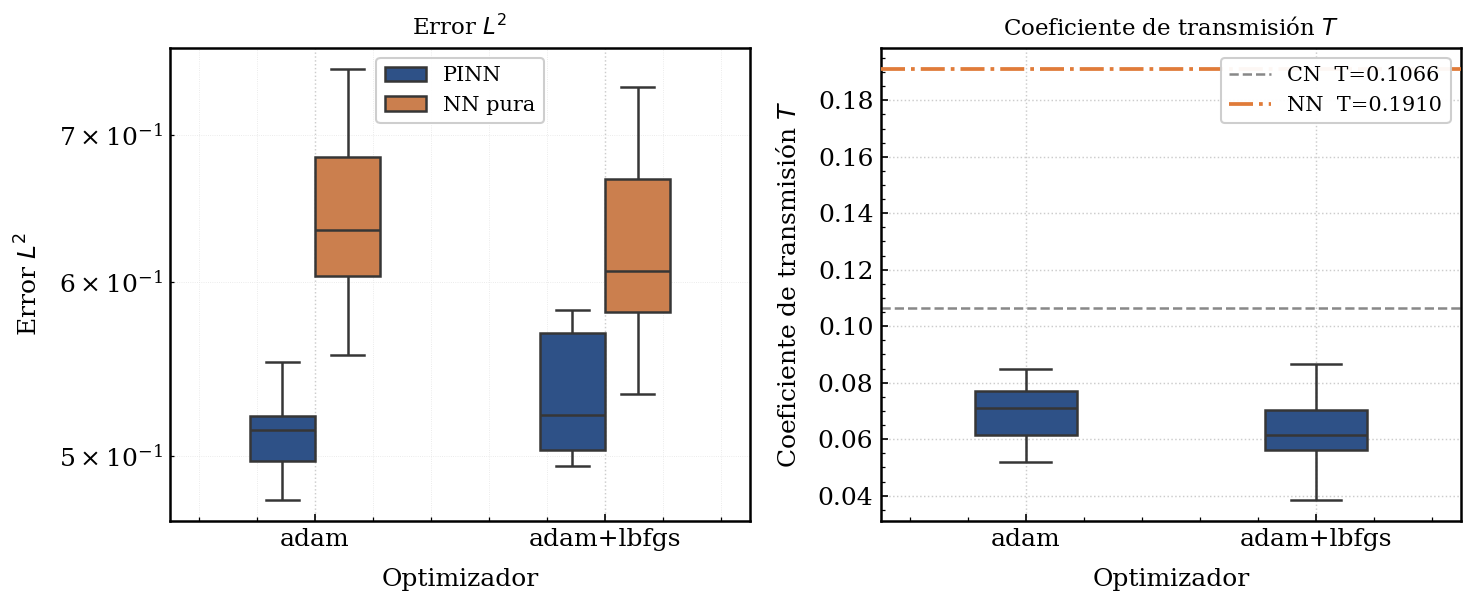

adam: L2=5.1203e-01 ± 2.4472e-02 | NN=6.4365e-01 ± 5.7102e-02 | T=0.0691 ± 0.0106
adam+lbfgs: L2=5.3209e-01 ± 3.6089e-02 | NN=6.2313e-01 ± 6.0646e-02 | T=0.0617 ± 0.0141
T_cn: 0.1066


In [6]:
mask_eje3_tunnel = (
    df_tunnel["optimizer"].isin(["adam", "adam+lbfgs"]) &
    (df_tunnel["num_collocation"]     == BASE_TUNNEL["num_collocation"]) &
    (df_tunnel["num_train_points"]    == BASE_TUNNEL["num_train_points"]) &
    (df_tunnel["sampler"]             == BASE_TUNNEL["sampler"]) &
    (df_tunnel["warmup_epochs"]       == BASE_TUNNEL["warmup_epochs"]) &
    (df_tunnel["use_dynamic_weights"] == BASE_TUNNEL["use_dynamic_weights"]) &
    (df_tunnel["use_data_pinn"]       == BASE_TUNNEL["use_data_pinn"]) &
    (df_tunnel["hidden_layers"]       == BASE_TUNNEL["hidden_layers"]) &
    (df_tunnel["lr"]                  == BASE_TUNNEL["lr"]) &
    (df_tunnel["V0"]                  == BASE_TUNNEL["V0"])
)

df_eje3_tunnel_long = df_tunnel[mask_eje3_tunnel].melt(
    id_vars=["optimizer"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df_eje3_tunnel_long, x="optimizer", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=10, title=None)
ax.set_xlabel("Optimizador", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: coeficiente de transmisión ─────────────────────────────
ax = axes[1]
sns.boxplot(
    data=df_tunnel[mask_eje3_tunnel], x="optimizer", y="T_pinn",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(df_base_tunnel["T_cn"].mean(), color=C_CN, linewidth=1.2,
           linestyle="--", label=f"CN  T={df_base_tunnel['T_cn'].mean():.4f}", zorder=2)
ax.axhline(df_base_tunnel["T_nn"].mean(), color=C_NN, linewidth=1.8,
           linestyle="-.", label=f"NN  T={df_base_tunnel['T_nn'].mean():.4f}", zorder=3)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Optimizador", labelpad=8)
ax.set_ylabel("Coeficiente de transmisión $T$", labelpad=8)
ax.set_title("Coeficiente de transmisión $T$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje3_optimizer.png", dpi=300, bbox_inches="tight")
plt.show()

for opt, grp in df_tunnel[mask_eje3_tunnel].groupby("optimizer"):
    print(f"{opt}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e} "
          f"| T={grp['T_pinn'].mean():.4f} ± {grp['T_pinn'].std():.4f}")
print(f"T_cn: {df_base_tunnel['T_cn'].mean():.4f}")

## Eje 4 — Arquitectura

Se compara [64,64,64,64] (BASE) frente a [128,128,128,128]. El aumento de
capacidad afecta tanto a la PINN como a la NN, por lo que se incluyen ambas
en el panel de error L2. Para el túnel se usa una red más profunda que en
los sistemas anteriores dado que la solución es compleja y evoluciona en 2D.

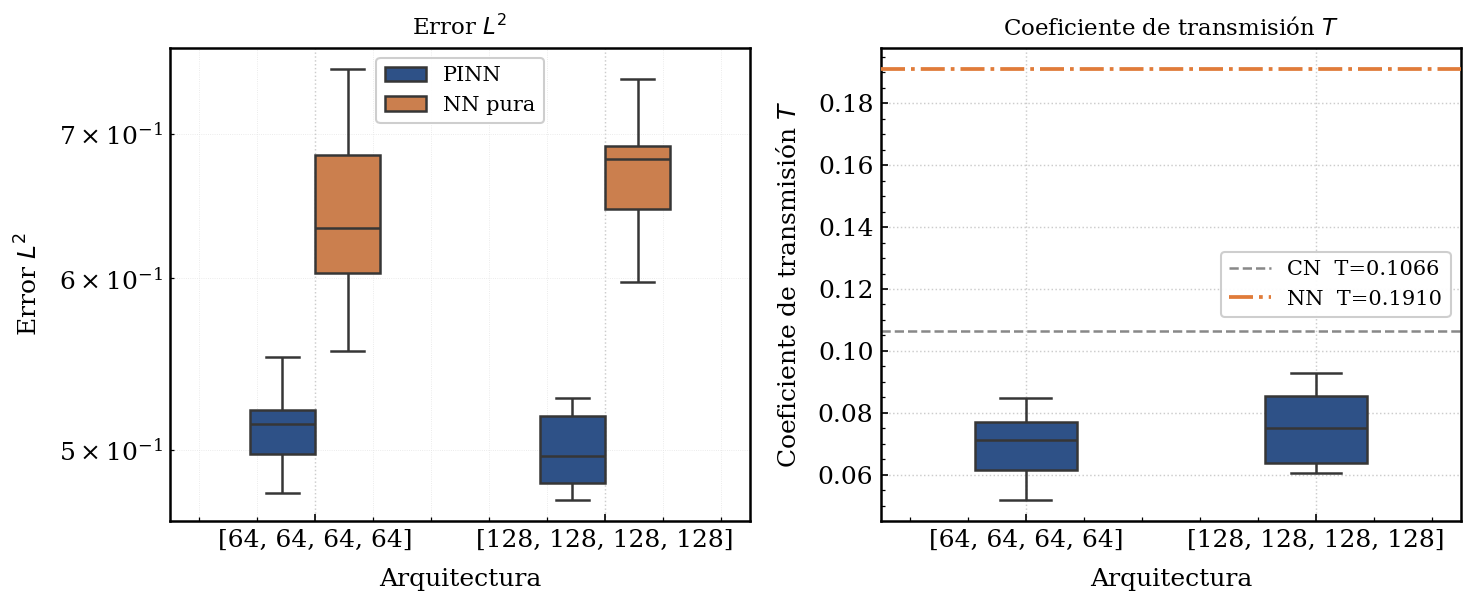

[128, 128, 128, 128]: L2=4.9945e-01 ± 2.1101e-02 | NN=6.7344e-01 ± 6.5963e-02 | T=0.0750 ± 0.0121
[64, 64, 64, 64]: L2=5.1203e-01 ± 2.4472e-02 | NN=6.4365e-01 ± 5.7102e-02 | T=0.0691 ± 0.0106
T_cn: 0.1066


In [7]:
mask_eje4_tunnel = (
    df_tunnel["hidden_layers"].isin(["[64, 64, 64, 64]", "[128, 128, 128, 128]"]) &
    (df_tunnel["num_collocation"]     == BASE_TUNNEL["num_collocation"]) &
    (df_tunnel["num_train_points"]    == BASE_TUNNEL["num_train_points"]) &
    (df_tunnel["sampler"]             == BASE_TUNNEL["sampler"]) &
    (df_tunnel["warmup_epochs"]       == BASE_TUNNEL["warmup_epochs"]) &
    (df_tunnel["use_dynamic_weights"] == BASE_TUNNEL["use_dynamic_weights"]) &
    (df_tunnel["use_data_pinn"]       == BASE_TUNNEL["use_data_pinn"]) &
    (df_tunnel["optimizer"]           == BASE_TUNNEL["optimizer"]) &
    (df_tunnel["lr"]                  == BASE_TUNNEL["lr"]) &
    (df_tunnel["V0"]                  == BASE_TUNNEL["V0"])
)

df_eje4_tunnel_long = df_tunnel[mask_eje4_tunnel].melt(
    id_vars=["hidden_layers"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df_eje4_tunnel_long, x="hidden_layers", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=10, title=None)
ax.set_xlabel("Arquitectura", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: coeficiente de transmisión ─────────────────────────────
ax = axes[1]
sns.boxplot(
    data=df_tunnel[mask_eje4_tunnel], x="hidden_layers", y="T_pinn",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(df_base_tunnel["T_cn"].mean(), color=C_CN, linewidth=1.2,
           linestyle="--", label=f"CN  T={df_base_tunnel['T_cn'].mean():.4f}", zorder=2)
ax.axhline(df_base_tunnel["T_nn"].mean(), color=C_NN, linewidth=1.8,
           linestyle="-.", label=f"NN  T={df_base_tunnel['T_nn'].mean():.4f}", zorder=3)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Arquitectura", labelpad=8)
ax.set_ylabel("Coeficiente de transmisión $T$", labelpad=8)
ax.set_title("Coeficiente de transmisión $T$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje4_architecture.png", dpi=300, bbox_inches="tight")
plt.show()

for arch, grp in df_tunnel[mask_eje4_tunnel].groupby("hidden_layers"):
    print(f"{arch}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e} "
          f"| T={grp['T_pinn'].mean():.4f} ± {grp['T_pinn'].std():.4f}")
print(f"T_cn: {df_base_tunnel['T_cn'].mean():.4f}")

## Eje 5 — Learning rate

Se comparan dos tasas de aprendizaje: 0.001 (BASE) y 0.01. Afecta tanto
a la PINN como a la NN, por lo que se incluyen ambas en el panel de error L2.

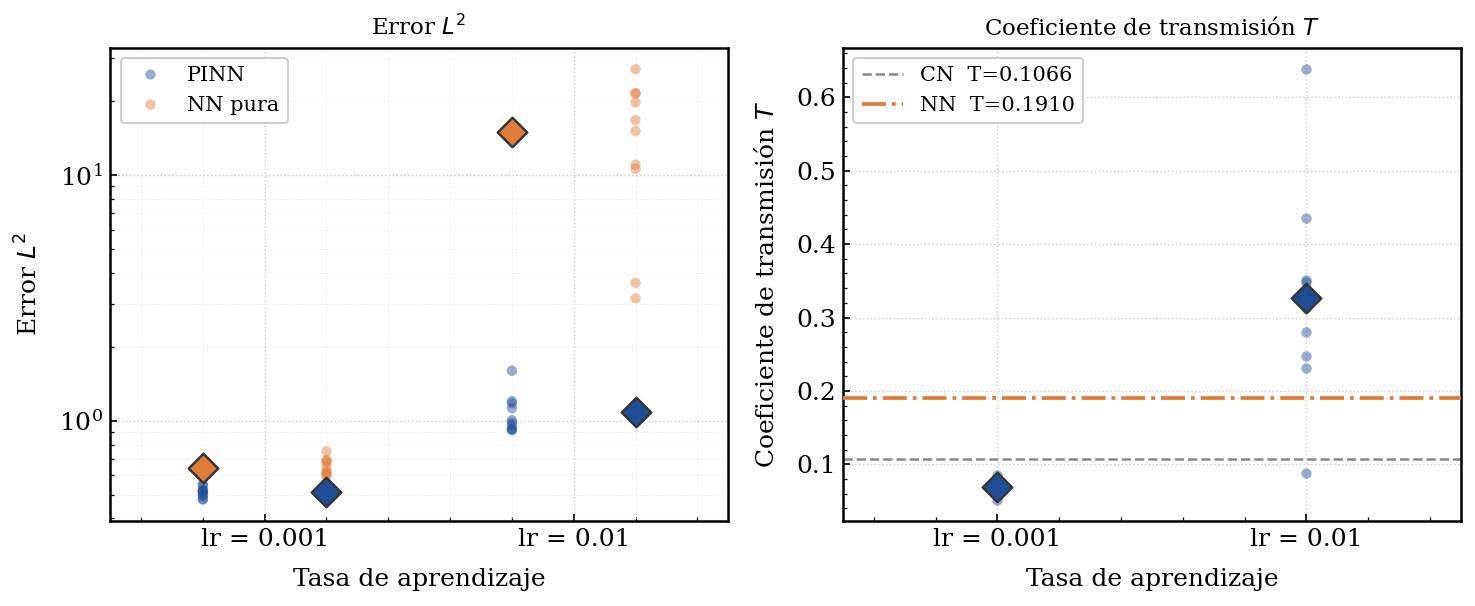

lr=0.001: L2=5.1203e-01 ± 2.4472e-02 | NN=6.4365e-01 ± 5.7102e-02 | T=0.0691 ± 0.0106
lr=0.01: L2=1.0807e+00 ± 2.1076e-01 | NN=1.5005e+01 ± 7.8803e+00 | T=0.3259 ± 0.1432
T_cn: 0.1066


In [8]:
mask_eje5_tunnel = (
    df_tunnel["lr"].isin([0.001, 0.01]) &
    (df_tunnel["num_collocation"]     == BASE_TUNNEL["num_collocation"]) &
    (df_tunnel["num_train_points"]    == BASE_TUNNEL["num_train_points"]) &
    (df_tunnel["sampler"]             == BASE_TUNNEL["sampler"]) &
    (df_tunnel["warmup_epochs"]       == BASE_TUNNEL["warmup_epochs"]) &
    (df_tunnel["use_dynamic_weights"] == BASE_TUNNEL["use_dynamic_weights"]) &
    (df_tunnel["use_data_pinn"]       == BASE_TUNNEL["use_data_pinn"]) &
    (df_tunnel["optimizer"]           == BASE_TUNNEL["optimizer"]) &
    (df_tunnel["hidden_layers"]       == BASE_TUNNEL["hidden_layers"]) &
    (df_tunnel["V0"]                  == BASE_TUNNEL["V0"])
)

df_eje5_tunnel = df_tunnel[mask_eje5_tunnel].copy()
df_eje5_tunnel["lr_label"] = df_eje5_tunnel["lr"].map(
    {0.001: "lr = 0.001", 0.01: "lr = 0.01"}
)

df_eje5_tunnel_long = df_eje5_tunnel.melt(
    id_vars=["lr_label"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.stripplot(
    data=df_eje5_tunnel_long, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=5, alpha=0.45, jitter=False, ax=ax
)
means_l2 = df_eje5_tunnel_long.groupby(["lr_label", "modelo"])["error_l2"].mean().reset_index()
sns.stripplot(
    data=means_l2, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=10, marker="D", jitter=False,
    linewidth=1.2, ax=ax, legend=False
)
handles, labels = ax.get_legend_handles_labels()
seen = set(); h, l = [], []
for handle, label in zip(handles, labels):
    if label not in seen:
        seen.add(label); h.append(handle); l.append(label)
ax.legend(h, l, frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Tasa de aprendizaje", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: coeficiente de transmisión ─────────────────────────────
ax = axes[1]
sns.stripplot(
    data=df_eje5_tunnel, x="lr_label", y="T_pinn",
    color=C_PINN, order=["lr = 0.001", "lr = 0.01"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_T = df_eje5_tunnel.groupby("lr_label")["T_pinn"].mean().reset_index()
sns.stripplot(
    data=means_T, x="lr_label", y="T_pinn",
    color=C_PINN, order=["lr = 0.001", "lr = 0.01"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(df_base_tunnel["T_cn"].mean(), color=C_CN, linewidth=1.2,
           linestyle="--", label=f"CN  T={df_base_tunnel['T_cn'].mean():.4f}", zorder=2)
ax.axhline(df_base_tunnel["T_nn"].mean(), color=C_NN, linewidth=1.8,
           linestyle="-.", label=f"NN  T={df_base_tunnel['T_nn'].mean():.4f}", zorder=3)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Tasa de aprendizaje", labelpad=8)
ax.set_ylabel("Coeficiente de transmisión $T$", labelpad=8)
ax.set_title("Coeficiente de transmisión $T$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje5_lr.png", dpi=300, bbox_inches="tight")
plt.show()

for lr_val, grp in df_tunnel[mask_eje5_tunnel].groupby("lr"):
    print(f"lr={lr_val}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e} "
          f"| T={grp['T_pinn'].mean():.4f} ± {grp['T_pinn'].std():.4f}")
print(f"T_cn: {df_base_tunnel['T_cn'].mean():.4f}")

## Eje 6 — Warmup epochs

El warmup es el periodo inicial en el que la pérdida física (TDSE) se mantiene
desactivada mediante un factor de rampa lineal, permitiendo que la red aprenda
primero a satisfacer las condiciones iniciales y de contorno antes de introducir
la restricción diferencial. Se comparan cuatro valores: 0 (sin warmup), 2500,
5000 (BASE) y 7500. La NN pura es insensible a este parámetro y se omite
del panel de error L2.

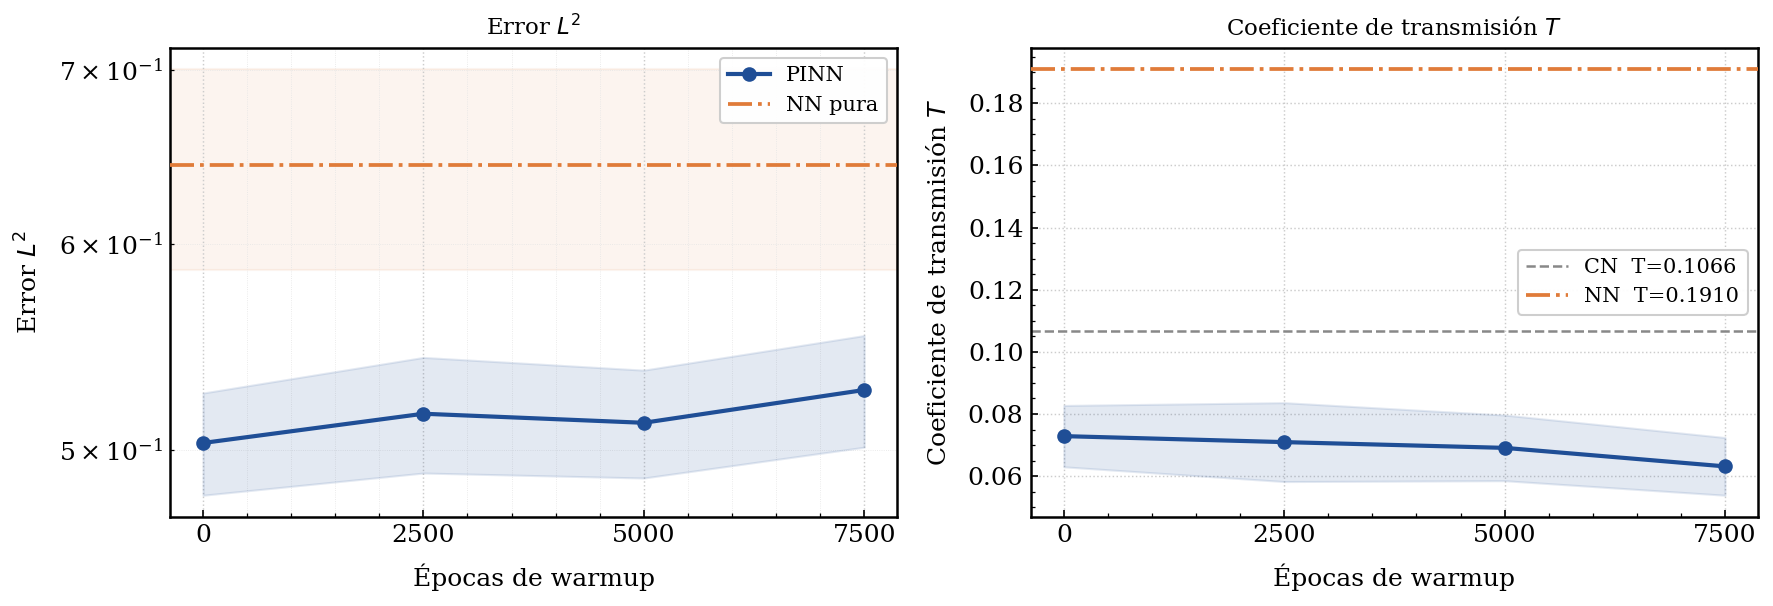

  warmup      PINN L2     T_pinn    T_std
       0   5.0294e-01     0.0729   0.0099
    2500   5.1616e-01     0.0710   0.0127
    5000   5.1203e-01     0.0691   0.0106
    7500   5.2715e-01     0.0632   0.0093

NN pura: 6.4365e-01
T_cn:    0.1066


In [9]:
configs_eje6 = [0, 2500, 5000, 7500]

mask_eje6_tunnel = (
    df_tunnel["warmup_epochs"].isin(configs_eje6) &
    (df_tunnel["num_collocation"]     == BASE_TUNNEL["num_collocation"]) &
    (df_tunnel["num_train_points"]    == BASE_TUNNEL["num_train_points"]) &
    (df_tunnel["sampler"]             == BASE_TUNNEL["sampler"]) &
    (df_tunnel["use_dynamic_weights"] == BASE_TUNNEL["use_dynamic_weights"]) &
    (df_tunnel["use_data_pinn"]       == BASE_TUNNEL["use_data_pinn"]) &
    (df_tunnel["optimizer"]           == BASE_TUNNEL["optimizer"]) &
    (df_tunnel["hidden_layers"]       == BASE_TUNNEL["hidden_layers"]) &
    (df_tunnel["lr"]                  == BASE_TUNNEL["lr"]) &
    (df_tunnel["V0"]                  == BASE_TUNNEL["V0"])
)

df_eje6_tunnel = df_tunnel[mask_eje6_tunnel].groupby("warmup_epochs").agg(
    pinn_mean  =("error_l2_pinn", "mean"),
    pinn_std   =("error_l2_pinn", "std"),
    T_pinn_mean=("T_pinn",        "mean"),
    T_pinn_std =("T_pinn",        "std"),
).reset_index()

x = df_eje6_tunnel["warmup_epochs"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, df_eje6_tunnel["pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3, label="PINN")
ax.fill_between(x,
    df_eje6_tunnel["pinn_mean"] - df_eje6_tunnel["pinn_std"],
    df_eje6_tunnel["pinn_mean"] + df_eje6_tunnel["pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(df_base_tunnel["error_l2_nn"].mean(), color=C_NN,
           linewidth=1.8, linestyle="-.", label="NN pura", zorder=3)
ax.axhspan(
    df_base_tunnel["error_l2_nn"].mean() - df_base_tunnel["error_l2_nn"].std(),
    df_base_tunnel["error_l2_nn"].mean() + df_base_tunnel["error_l2_nn"].std(),
    color=C_NN, alpha=0.08, zorder=1)
ax.set_xlabel("Épocas de warmup", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel derecho: coeficiente de transmisión ─────────────────────────────
ax = axes[1]
ax.plot(x, df_eje6_tunnel["T_pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3)
ax.fill_between(x,
    df_eje6_tunnel["T_pinn_mean"] - df_eje6_tunnel["T_pinn_std"],
    df_eje6_tunnel["T_pinn_mean"] + df_eje6_tunnel["T_pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(df_base_tunnel["T_cn"].mean(), color=C_CN, linewidth=1.2,
           linestyle="--", label=f"CN  T={df_base_tunnel['T_cn'].mean():.4f}", zorder=2)
ax.axhline(df_base_tunnel["T_nn"].mean(), color=C_NN, linewidth=1.8,
           linestyle="-.", label=f"NN  T={df_base_tunnel['T_nn'].mean():.4f}", zorder=3)
ax.set_xlabel("Épocas de warmup", labelpad=8)
ax.set_ylabel("Coeficiente de transmisión $T$", labelpad=8)
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Coeficiente de transmisión $T$", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje6_warmup.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'warmup':>8} {'PINN L2':>12} {'T_pinn':>10} {'T_std':>8}")
for _, row in df_eje6_tunnel.iterrows():
    print(f"{int(row['warmup_epochs']):>8} {row['pinn_mean']:>12.4e} "
          f"{row['T_pinn_mean']:>10.4f} {row['T_pinn_std']:>8.4f}")
print(f"\nNN pura: {df_base_tunnel['error_l2_nn'].mean():.4e}")
print(f"T_cn:    {df_base_tunnel['T_cn'].mean():.4f}")

## Eje 7 — Altura de barrera V₀

Este eje es exclusivo del efecto túnel. Se estudia cómo varía el rendimiento
de la PINN al cambiar la altura de la barrera de potencial: 2.5 (barrera baja,
E/V₀ ≈ 0.8, régimen casi clásico), 3.0 (BASE, E/V₀ ≈ 0.67, túnel moderado)
y 5.0 (barrera alta, E/V₀ = 0.4, túnel fuerte). La energía cinética del
paquete de onda es E ≈ k₀²/2 = 2.0 en todos los casos. Tanto la dificultad
del problema como el coeficiente de transmisión real cambian con V₀, por lo
que se analiza T_cn de cada configuración como referencia propia.

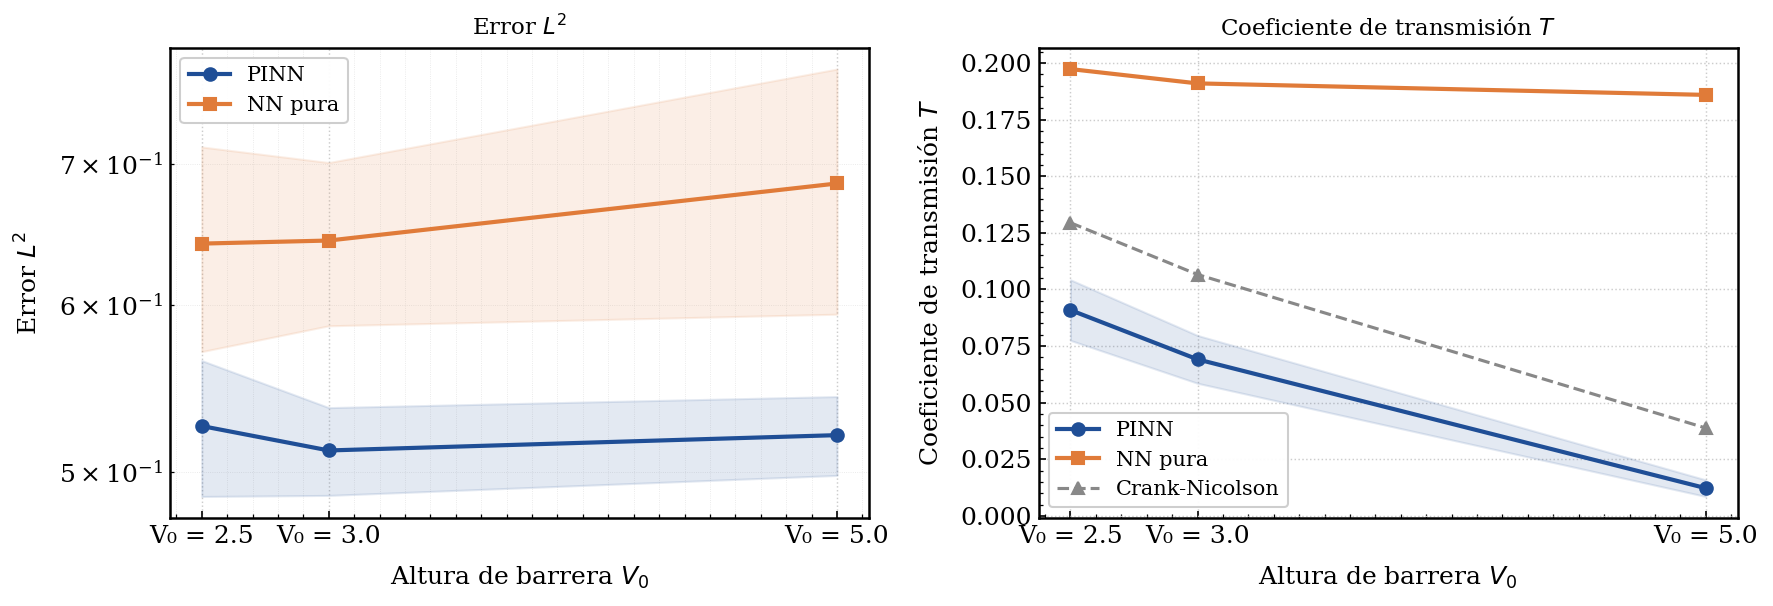

   V0      PINN L2        NN L2   T_pinn     T_nn     T_cn
  2.5   5.2585e-01   6.4150e-01   0.0909   0.1973   0.1294
  3.0   5.1203e-01   6.4365e-01   0.0691   0.1910   0.1066
  5.0   5.2065e-01   6.8494e-01   0.0122   0.1859   0.0388


In [10]:
configs_eje7 = [2.5, 3.0, 5.0]

mask_eje7_tunnel = (
    df_tunnel["V0"].isin(configs_eje7) &
    (df_tunnel["num_collocation"]     == BASE_TUNNEL["num_collocation"]) &
    (df_tunnel["num_train_points"]    == BASE_TUNNEL["num_train_points"]) &
    (df_tunnel["sampler"]             == BASE_TUNNEL["sampler"]) &
    (df_tunnel["warmup_epochs"]       == BASE_TUNNEL["warmup_epochs"]) &
    (df_tunnel["use_dynamic_weights"] == BASE_TUNNEL["use_dynamic_weights"]) &
    (df_tunnel["use_data_pinn"]       == BASE_TUNNEL["use_data_pinn"]) &
    (df_tunnel["optimizer"]           == BASE_TUNNEL["optimizer"]) &
    (df_tunnel["hidden_layers"]       == BASE_TUNNEL["hidden_layers"]) &
    (df_tunnel["lr"]                  == BASE_TUNNEL["lr"])
)

df_eje7_tunnel = df_tunnel[mask_eje7_tunnel].groupby("V0").agg(
    pinn_mean  =("error_l2_pinn", "mean"),
    pinn_std   =("error_l2_pinn", "std"),
    nn_mean    =("error_l2_nn",   "mean"),
    nn_std     =("error_l2_nn",   "std"),
    T_pinn_mean=("T_pinn",        "mean"),
    T_pinn_std =("T_pinn",        "std"),
    T_nn_mean  =("T_nn",          "mean"),
    T_cn_mean  =("T_cn",          "mean"),
).reset_index()

x       = df_eje7_tunnel["V0"].values
xlabels = [f"V₀ = {v}" for v in x]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, df_eje7_tunnel["pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, label="PINN", zorder=3)
ax.fill_between(x,
    df_eje7_tunnel["pinn_mean"] - df_eje7_tunnel["pinn_std"],
    df_eje7_tunnel["pinn_mean"] + df_eje7_tunnel["pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, df_eje7_tunnel["nn_mean"], "s-", color=C_NN, linewidth=2,
        markersize=6, label="NN pura", zorder=3)
ax.fill_between(x,
    df_eje7_tunnel["nn_mean"] - df_eje7_tunnel["nn_std"],
    df_eje7_tunnel["nn_mean"] + df_eje7_tunnel["nn_std"],
    color=C_NN, alpha=0.12, zorder=2)
ax.set_xlabel("Altura de barrera $V_0$", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel derecho: coeficiente de transmisión ─────────────────────────────
ax = axes[1]
ax.plot(x, df_eje7_tunnel["T_pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, label="PINN", zorder=3)
ax.fill_between(x,
    df_eje7_tunnel["T_pinn_mean"] - df_eje7_tunnel["T_pinn_std"],
    df_eje7_tunnel["T_pinn_mean"] + df_eje7_tunnel["T_pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, df_eje7_tunnel["T_nn_mean"], "s-", color=C_NN, linewidth=2,
        markersize=6, label="NN pura", zorder=3)
ax.plot(x, df_eje7_tunnel["T_cn_mean"], "^--", color=C_CN, linewidth=1.5,
        markersize=6, label="Crank-Nicolson", zorder=2)
ax.set_xlabel("Altura de barrera $V_0$", labelpad=8)
ax.set_ylabel("Coeficiente de transmisión $T$", labelpad=8)
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Coeficiente de transmisión $T$", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje7_V0.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'V0':>5} {'PINN L2':>12} {'NN L2':>12} {'T_pinn':>8} {'T_nn':>8} {'T_cn':>8}")
for _, row in df_eje7_tunnel.iterrows():
    print(f"{row['V0']:>5.1f} {row['pinn_mean']:>12.4e} {row['nn_mean']:>12.4e} "
          f"{row['T_pinn_mean']:>8.4f} {row['T_nn_mean']:>8.4f} {row['T_cn_mean']:>8.4f}")

## Eje 8 — Puntos de entrenamiento

Se varía el número de puntos de datos dispersos en el dominio 2D (x,t)
interpolados desde Crank-Nicolson: 20, 50, 100 (BASE) y 200. Tanto la
PINN como la NN dependen de estos puntos, por lo que se incluyen ambas
en el panel de error L2. Para la PINN, estos datos actúan como supervisión
adicional junto a la restricción física.

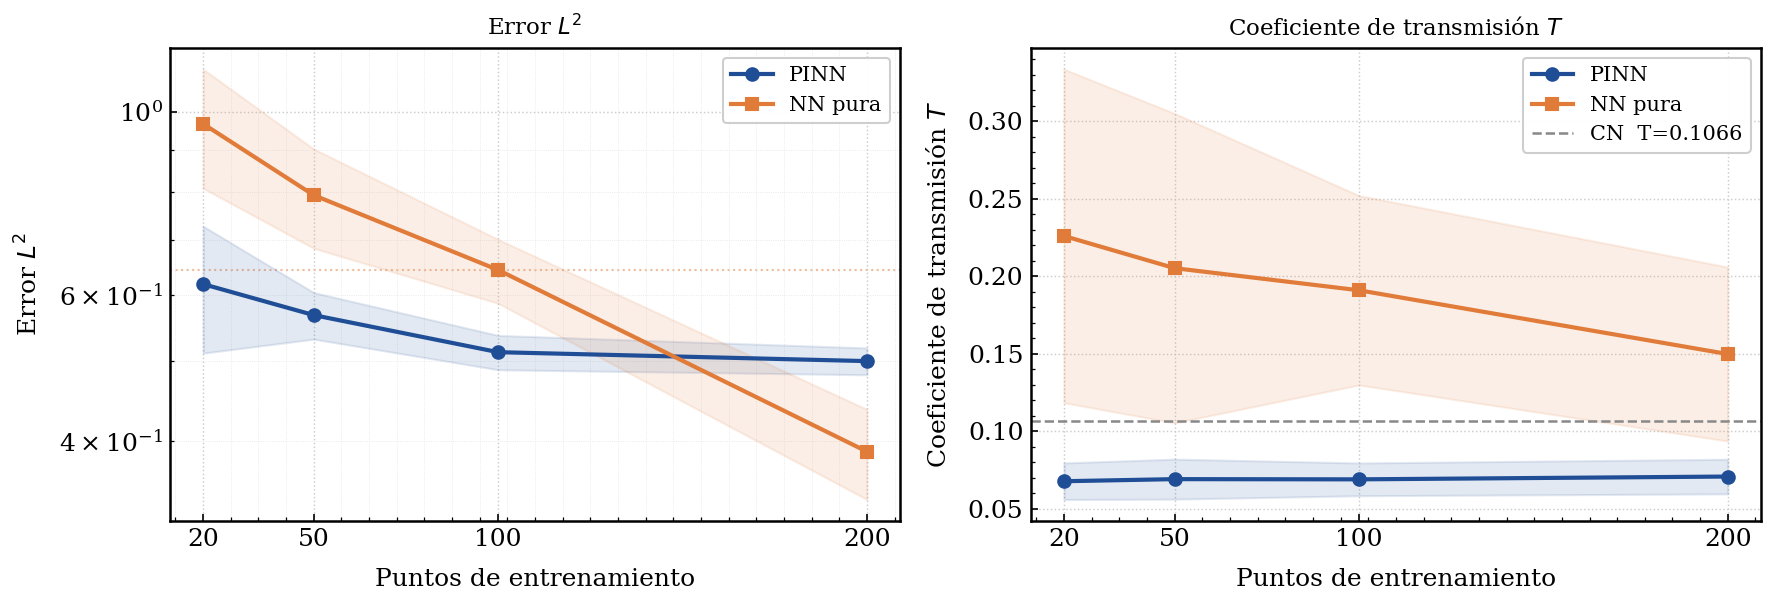

 pts      PINN L2        NN L2   T_pinn     T_nn
  20   6.1885e-01   9.6679e-01   0.0679   0.2260
  50   5.6767e-01   7.9256e-01   0.0692   0.2052
 100   5.1203e-01   6.4365e-01   0.0691   0.1910
 200   4.9945e-01   3.8822e-01   0.0709   0.1499

T_cn: 0.1066


In [11]:
configs_eje8 = [20, 50, 100, 200]

mask_eje8_tunnel = (
    df_tunnel["num_train_points"].isin(configs_eje8) &
    (df_tunnel["num_collocation"]     == BASE_TUNNEL["num_collocation"]) &
    (df_tunnel["sampler"]             == BASE_TUNNEL["sampler"]) &
    (df_tunnel["warmup_epochs"]       == BASE_TUNNEL["warmup_epochs"]) &
    (df_tunnel["use_dynamic_weights"] == BASE_TUNNEL["use_dynamic_weights"]) &
    (df_tunnel["use_data_pinn"]       == BASE_TUNNEL["use_data_pinn"]) &
    (df_tunnel["optimizer"]           == BASE_TUNNEL["optimizer"]) &
    (df_tunnel["hidden_layers"]       == BASE_TUNNEL["hidden_layers"]) &
    (df_tunnel["lr"]                  == BASE_TUNNEL["lr"]) &
    (df_tunnel["V0"]                  == BASE_TUNNEL["V0"])
)

df_eje8_tunnel = df_tunnel[mask_eje8_tunnel].groupby("num_train_points").agg(
    pinn_mean  =("error_l2_pinn", "mean"),
    pinn_std   =("error_l2_pinn", "std"),
    nn_mean    =("error_l2_nn",   "mean"),
    nn_std     =("error_l2_nn",   "std"),
    T_pinn_mean=("T_pinn",        "mean"),
    T_pinn_std =("T_pinn",        "std"),
    T_nn_mean  =("T_nn",          "mean"),
    T_nn_std   =("T_nn",          "std"),
).reset_index()

x = df_eje8_tunnel["num_train_points"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, df_eje8_tunnel["pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, label="PINN", zorder=3)
ax.fill_between(x,
    df_eje8_tunnel["pinn_mean"] - df_eje8_tunnel["pinn_std"],
    df_eje8_tunnel["pinn_mean"] + df_eje8_tunnel["pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, df_eje8_tunnel["nn_mean"], "s-", color=C_NN, linewidth=2,
        markersize=6, label="NN pura", zorder=3)
ax.fill_between(x,
    df_eje8_tunnel["nn_mean"] - df_eje8_tunnel["nn_std"],
    df_eje8_tunnel["nn_mean"] + df_eje8_tunnel["nn_std"],
    color=C_NN, alpha=0.12, zorder=2)
ax.axhline(df_base_tunnel["error_l2_nn"].mean(), color=C_NN,
           linewidth=1.0, linestyle=":", alpha=0.5, zorder=1)
ax.set_xlabel("Puntos de entrenamiento", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel derecho: coeficiente de transmisión ─────────────────────────────
ax = axes[1]
ax.plot(x, df_eje8_tunnel["T_pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, label="PINN", zorder=3)
ax.fill_between(x,
    df_eje8_tunnel["T_pinn_mean"] - df_eje8_tunnel["T_pinn_std"],
    df_eje8_tunnel["T_pinn_mean"] + df_eje8_tunnel["T_pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, df_eje8_tunnel["T_nn_mean"], "s-", color=C_NN, linewidth=2,
        markersize=6, label="NN pura", zorder=3)
ax.fill_between(x,
    df_eje8_tunnel["T_nn_mean"] - df_eje8_tunnel["T_nn_std"],
    df_eje8_tunnel["T_nn_mean"] + df_eje8_tunnel["T_nn_std"],
    color=C_NN, alpha=0.12, zorder=2)
ax.axhline(df_base_tunnel["T_cn"].mean(), color=C_CN, linewidth=1.2,
           linestyle="--", label=f"CN  T={df_base_tunnel['T_cn'].mean():.4f}", zorder=2)
ax.set_xlabel("Puntos de entrenamiento", labelpad=8)
ax.set_ylabel("Coeficiente de transmisión $T$", labelpad=8)
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Coeficiente de transmisión $T$", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje8_train_points.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'pts':>4} {'PINN L2':>12} {'NN L2':>12} {'T_pinn':>8} {'T_nn':>8}")
for _, row in df_eje8_tunnel.iterrows():
    print(f"{int(row['num_train_points']):>4} {row['pinn_mean']:>12.4e} "
          f"{row['nn_mean']:>12.4e} {row['T_pinn_mean']:>8.4f} "
          f"{row['T_nn_mean']:>8.4f}")
print(f"\nT_cn: {df_base_tunnel['T_cn'].mean():.4f}")

## Eje 9 — PINN con y sin datos

Se compara la configuración BASE (PINN con datos dispersos de CN) frente a
una PINN puramente sin supervisión, que solo dispone de las condiciones
iniciales, de contorno y la restricción física de la TDSE. Este eje es
especialmente relevante para el túnel: sin datos, la PINN debe aprender
la dinámica completa del paquete de onda únicamente a partir de la ecuación,
lo que supone un reto considerablemente mayor que en sistemas más simples.
La NN pura siempre usa datos y se mantiene como referencia.

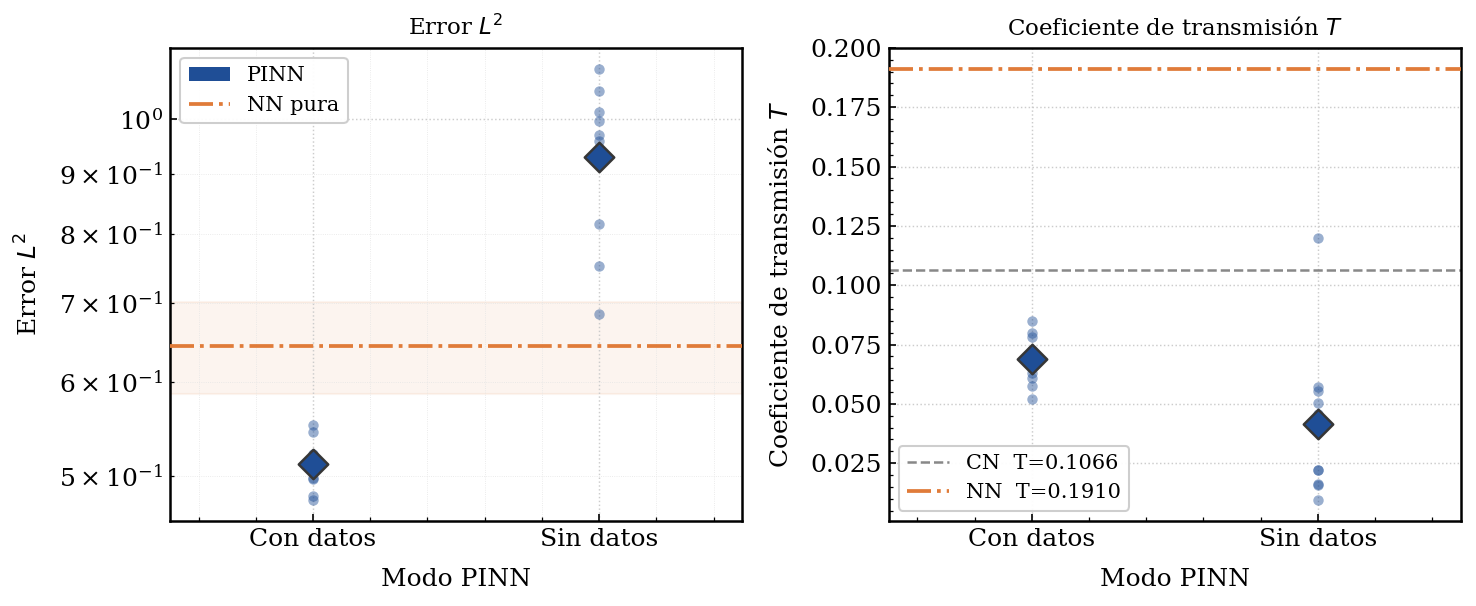

Con datos: L2=5.1203e-01 ± 2.4472e-02 | T=0.0691 ± 0.0106
Sin datos: L2=9.2930e-01 ± 1.3538e-01 | T=0.0414 ± 0.0328
NN pura: 6.4365e-01 ± 5.7102e-02
T_cn:    0.1066


In [12]:
mask_eje9_tunnel = (
    df_tunnel["use_data_pinn"].isin([True, False]) &
    (df_tunnel["num_collocation"]     == BASE_TUNNEL["num_collocation"]) &
    (df_tunnel["num_train_points"]    == BASE_TUNNEL["num_train_points"]) &
    (df_tunnel["sampler"]             == BASE_TUNNEL["sampler"]) &
    (df_tunnel["warmup_epochs"]       == BASE_TUNNEL["warmup_epochs"]) &
    (df_tunnel["use_dynamic_weights"] == BASE_TUNNEL["use_dynamic_weights"]) &
    (df_tunnel["optimizer"]           == BASE_TUNNEL["optimizer"]) &
    (df_tunnel["hidden_layers"]       == BASE_TUNNEL["hidden_layers"]) &
    (df_tunnel["lr"]                  == BASE_TUNNEL["lr"]) &
    (df_tunnel["V0"]                  == BASE_TUNNEL["V0"])
)

df_eje9_tunnel = df_tunnel[mask_eje9_tunnel].copy()
df_eje9_tunnel["modo"] = df_eje9_tunnel["use_data_pinn"].map(
    {True: "Con datos", False: "Sin datos"}
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.stripplot(
    data=df_eje9_tunnel, x="modo", y="error_l2_pinn",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_l2 = df_eje9_tunnel.groupby("modo")["error_l2_pinn"].mean().reset_index()
sns.stripplot(
    data=means_l2, x="modo", y="error_l2_pinn",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(df_base_tunnel["error_l2_nn"].mean(), color=C_NN,
           linewidth=1.8, linestyle="-.", label="NN pura", zorder=3)
ax.axhspan(
    df_base_tunnel["error_l2_nn"].mean() - df_base_tunnel["error_l2_nn"].std(),
    df_base_tunnel["error_l2_nn"].mean() + df_base_tunnel["error_l2_nn"].std(),
    color=C_NN, alpha=0.08, zorder=1)
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Modo PINN", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: coeficiente de transmisión ─────────────────────────────
ax = axes[1]
sns.stripplot(
    data=df_eje9_tunnel, x="modo", y="T_pinn",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_T = df_eje9_tunnel.groupby("modo")["T_pinn"].mean().reset_index()
sns.stripplot(
    data=means_T, x="modo", y="T_pinn",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(df_base_tunnel["T_cn"].mean(), color=C_CN, linewidth=1.2,
           linestyle="--", label=f"CN  T={df_base_tunnel['T_cn'].mean():.4f}", zorder=2)
ax.axhline(df_base_tunnel["T_nn"].mean(), color=C_NN, linewidth=1.8,
           linestyle="-.", label=f"NN  T={df_base_tunnel['T_nn'].mean():.4f}", zorder=3)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Modo PINN", labelpad=8)
ax.set_ylabel("Coeficiente de transmisión $T$", labelpad=8)
ax.set_title("Coeficiente de transmisión $T$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje9_use_data.png", dpi=300, bbox_inches="tight")
plt.show()

for modo, grp in df_eje9_tunnel.groupby("modo"):
    print(f"{modo}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| T={grp['T_pinn'].mean():.4f} ± {grp['T_pinn'].std():.4f}")
print(f"NN pura: {df_base_tunnel['error_l2_nn'].mean():.4e} ± {df_base_tunnel['error_l2_nn'].std():.4e}")
print(f"T_cn:    {df_base_tunnel['T_cn'].mean():.4f}")

## Eje 10 — Pesos dinámicos

Los pesos dinámicos reequilibran automáticamente las contribuciones de cada
término de la función de pérdida (física, IC, BC, normalización, datos)
durante el entrenamiento. Solo afectan a la PINN, por lo que se omite la NN
del panel de error L2. Para el túnel, donde la pérdida tiene cinco términos
con magnitudes muy dispares, el reequilibrio automático puede ser especialmente
relevante.

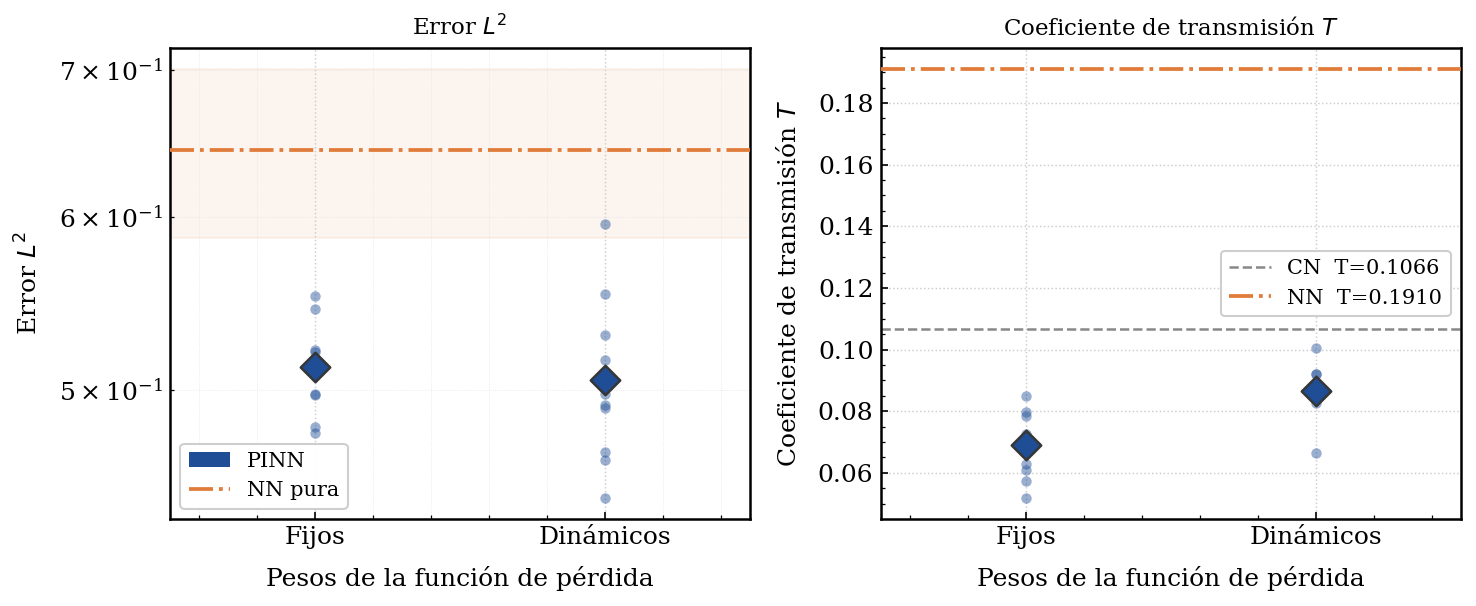

Dinámicos: L2=5.0547e-01 ± 4.4861e-02 | T=0.0866 ± 0.0087
Fijos: L2=5.1203e-01 ± 2.4472e-02 | T=0.0691 ± 0.0106
NN pura: 6.4365e-01 ± 5.7102e-02
T_cn:    0.1066


In [13]:
mask_eje10_tunnel = (
    (df_tunnel["num_collocation"]     == BASE_TUNNEL["num_collocation"]) &
    (df_tunnel["num_train_points"]    == BASE_TUNNEL["num_train_points"]) &
    (df_tunnel["sampler"]             == BASE_TUNNEL["sampler"]) &
    (df_tunnel["warmup_epochs"]       == BASE_TUNNEL["warmup_epochs"]) &
    (df_tunnel["use_data_pinn"]       == BASE_TUNNEL["use_data_pinn"]) &
    (df_tunnel["optimizer"]           == BASE_TUNNEL["optimizer"]) &
    (df_tunnel["hidden_layers"]       == BASE_TUNNEL["hidden_layers"]) &
    (df_tunnel["lr"]                  == BASE_TUNNEL["lr"]) &
    (df_tunnel["V0"]                  == BASE_TUNNEL["V0"])
)

df_eje10_tunnel = df_tunnel[mask_eje10_tunnel].copy()
df_eje10_tunnel["pesos"] = df_eje10_tunnel["use_dynamic_weights"].map(
    {False: "Fijos", True: "Dinámicos"}
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.stripplot(
    data=df_eje10_tunnel, x="pesos", y="error_l2_pinn",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_l2 = df_eje10_tunnel.groupby("pesos")["error_l2_pinn"].mean().reset_index()
sns.stripplot(
    data=means_l2, x="pesos", y="error_l2_pinn",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(df_base_tunnel["error_l2_nn"].mean(), color=C_NN,
           linewidth=1.8, linestyle="-.", label="NN pura", zorder=3)
ax.axhspan(
    df_base_tunnel["error_l2_nn"].mean() - df_base_tunnel["error_l2_nn"].std(),
    df_base_tunnel["error_l2_nn"].mean() + df_base_tunnel["error_l2_nn"].std(),
    color=C_NN, alpha=0.08, zorder=1)
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Pesos de la función de pérdida", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: coeficiente de transmisión ─────────────────────────────
ax = axes[1]
sns.stripplot(
    data=df_eje10_tunnel, x="pesos", y="T_pinn",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_T = df_eje10_tunnel.groupby("pesos")["T_pinn"].mean().reset_index()
sns.stripplot(
    data=means_T, x="pesos", y="T_pinn",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(df_base_tunnel["T_cn"].mean(), color=C_CN, linewidth=1.2,
           linestyle="--", label=f"CN  T={df_base_tunnel['T_cn'].mean():.4f}", zorder=2)
ax.axhline(df_base_tunnel["T_nn"].mean(), color=C_NN, linewidth=1.8,
           linestyle="-.", label=f"NN  T={df_base_tunnel['T_nn'].mean():.4f}", zorder=3)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Pesos de la función de pérdida", labelpad=8)
ax.set_ylabel("Coeficiente de transmisión $T$", labelpad=8)
ax.set_title("Coeficiente de transmisión $T$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje10_dynamic_weights.png", dpi=300, bbox_inches="tight")
plt.show()

for pesos, grp in df_eje10_tunnel.groupby("pesos"):
    print(f"{pesos}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| T={grp['T_pinn'].mean():.4f} ± {grp['T_pinn'].std():.4f}")
print(f"NN pura: {df_base_tunnel['error_l2_nn'].mean():.4e} ± {df_base_tunnel['error_l2_nn'].std():.4e}")
print(f"T_cn:    {df_base_tunnel['T_cn'].mean():.4f}")

## Tabla resumen — todos los ejes

In [14]:
resumen_tunnel = []

# ── BASE ──────────────────────────────────────────────────────────────────
resumen_tunnel.append({
    "Eje":           "BASE",
    "Configuración": "—",
    "PINN L2 media": df_base_tunnel["error_l2_pinn"].mean(),
    "PINN L2 std":   df_base_tunnel["error_l2_pinn"].std(),
    "NN L2 media":   df_base_tunnel["error_l2_nn"].mean(),
    "NN L2 std":     df_base_tunnel["error_l2_nn"].std(),
    "T_pinn media":  df_base_tunnel["T_pinn"].mean(),
    "T_pinn std":    df_base_tunnel["T_pinn"].std(),
    "T_cn media":    df_base_tunnel["T_cn"].mean(),
    "N":             len(df_base_tunnel),
})

# ── Ejes ──────────────────────────────────────────────────────────────────
ejes_tunnel = [
    ("Eje 1 · Puntos colocación",  "num_collocation",     mask_eje1_tunnel),
    ("Eje 2 · Sampler",            "sampler",             mask_eje2_tunnel),
    ("Eje 3 · Optimizador",        "optimizer",           mask_eje3_tunnel),
    ("Eje 4 · Arquitectura",       "hidden_layers",       mask_eje4_tunnel),
    ("Eje 5 · Learning rate",      "lr",                  mask_eje5_tunnel),
    ("Eje 6 · Warmup",             "warmup_epochs",       mask_eje6_tunnel),
    ("Eje 7 · Barrera V₀",         "V0",                  mask_eje7_tunnel),
    ("Eje 8 · Puntos train",       "num_train_points",    mask_eje8_tunnel),
    ("Eje 9 · Con/sin datos",      "use_data_pinn",       mask_eje9_tunnel),
    ("Eje 10 · Pesos dinámicos",   "use_dynamic_weights", mask_eje10_tunnel),
]

for eje_label, col, mask in ejes_tunnel:
    for val, grp in df_tunnel[mask].groupby(col):
        resumen_tunnel.append({
            "Eje":           eje_label,
            "Configuración": str(val),
            "PINN L2 media": grp["error_l2_pinn"].mean(),
            "PINN L2 std":   grp["error_l2_pinn"].std(),
            "NN L2 media":   grp["error_l2_nn"].mean(),
            "NN L2 std":     grp["error_l2_nn"].std(),
            "T_pinn media":  grp["T_pinn"].mean(),
            "T_pinn std":    grp["T_pinn"].std(),
            "T_cn media":    grp["T_cn"].mean(),
            "N":             len(grp),
        })

# ── Formatear y mostrar ───────────────────────────────────────────────────
df_resumen_tunnel = pd.DataFrame(resumen_tunnel)

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

print(f"\n{'═'*140}")
print(f"{'EJE':<28} {'CONFIG':<22} {'PINN L2':>12} {'PINN std':>10} "
      f"{'NN L2':>12} {'NN std':>10} "
      f"{'T_pinn':>8} {'T_std':>7} {'T_cn':>8} {'N':>4}")
print(f"{'─'*140}")

eje_actual = None
for _, row in df_resumen_tunnel.iterrows():
    if row["Eje"] != eje_actual:
        if eje_actual is not None:
            print(f"{'─'*140}")
        eje_actual = row["Eje"]
    print(f"{row['Eje']:<28} {row['Configuración']:<22} "
          f"{row['PINN L2 media']:>12.3e} {row['PINN L2 std']:>10.3e} "
          f"{row['NN L2 media']:>12.3e} {row['NN L2 std']:>10.3e} "
          f"{row['T_pinn media']:>8.4f} {row['T_pinn std']:>7.4f} "
          f"{row['T_cn media']:>8.4f} {int(row['N']):>4}")

print(f"{'═'*140}")


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
EJE                          CONFIG                      PINN L2   PINN std        NN L2     NN std   T_pinn   T_std     T_cn    N
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BASE                         —                         5.120e-01  2.447e-02    6.436e-01  5.710e-02   0.0691  0.0106   0.1066   10
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Eje 1 · Puntos colocación    1000                      7.606e-01  1.001e-01    6.436e-01  5.710e-02   0.1101  0.0235   0.1066   10
Eje 1 · Puntos colocación    2000                      6.192e-01  8.081e-02    6.436e-01  5.710e-02   0.0740  0.0153   0.1066   10
Eje 1 · Puntos colocación    5000                   